<a href="https://colab.research.google.com/github/MichaelTRArruda/Consultas_procedimentos_saude_PCR/blob/main/Producao_Tematica_PSI_15289_C118964.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Produção Temática - PSI 15289
######--------------------------------------------------
##Michael Thomas Rodrigues de Arruda
#
##Previsão da Taxa de Inadimplência Agregada Mensal
######--------------------------------------------------
######Carregando dados das planilhas Contratos, Parcelas e Indicadores Macro

In [21]:
import pandas as pd
import numpy as np

df_contratos  = pd.read_excel("desafio_inadimplencia_caixa.xlsx", sheet_name=0)
df_parcelas   = pd.read_excel("desafio_inadimplencia_caixa.xlsx", sheet_name=1)
df_macro      = pd.read_excel("desafio_inadimplencia_caixa.xlsx", sheet_name=2)

df_contratos.head(), df_parcelas.head(), df_macro.head()

(   id_contrato dt_contratacao  vr_financiado  vr_entrada  tx_juros_anual  \
 0            1     2022-01-01      324632.90    59841.03            9.86   
 1            2     2022-01-01      318125.78   132286.64            9.47   
 2            3     2022-01-01      331881.90   124846.24            7.98   
 3            4     2022-01-01      134318.01    28375.09            5.79   
 4            5     2022-01-01      388430.10    85697.76            9.59   
 
    prazo_meses     faixa_renda  uf tipo_imovel programa_social  \
 0          240        3 a 6 SM  DF        Novo           Livre   
 1          240  Acima de 10 SM  PA       Usado            FGTS   
 2          360  Acima de 10 SM  PR       Usado            FGTS   
 3          360        3 a 6 SM  MS       Usado            MCMV   
 4          180       6 a 10 SM  AM       Usado           Livre   
 
    score_credito_contratacao    ltv  
 0                        737  84.44  
 1                        801  70.63  
 2             

######Conferir formatos e tipos das variáveis

In [13]:
print("CONTRATOS:")
print(df_contratos.info(), "\n")

print("PARCELAS:")
print(df_parcelas.info(), "\n")

print("Indicadores MACRO:")
print(df_macro.info())

CONTRATOS:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   id_contrato                10000 non-null  int64         
 1   dt_contratacao             10000 non-null  datetime64[ns]
 2   vr_financiado              10000 non-null  float64       
 3   vr_entrada                 10000 non-null  float64       
 4   tx_juros_anual             10000 non-null  float64       
 5   prazo_meses                10000 non-null  int64         
 6   faixa_renda                10000 non-null  object        
 7   uf                         10000 non-null  object        
 8   tipo_imovel                10000 non-null  object        
 9   programa_social            10000 non-null  object        
 10  score_credito_contratacao  10000 non-null  int64         
 11  ltv                        10000 non-null  float64       

###### Criar variável target de inadimplência por contrato

In [14]:
inadimplencia_por_contrato = (
    df_parcelas.groupby("id_contrato")["fl_inadimplente"]
    .max()  # se em algum mês foi 1, o contrato é 1
    .reset_index()
    .rename(columns={"fl_inadimplente": "inadimplente"})
)

inadimplencia_por_contrato.head()

,id_contrato,inadimplente
0,1,1
1,2,0
2,3,1
3,4,1
4,5,0


######Criando o Dataset para a regressão

In [15]:
df_modelo = df_contratos.merge(inadimplencia_por_contrato, on="id_contrato", how="left")
df_modelo.head()

,id_contrato,dt_contratacao,vr_financiado,vr_entrada,tx_juros_anual,prazo_meses,faixa_renda,uf,tipo_imovel,programa_social,score_credito_contratacao,ltv,inadimplente
0,1,2022-01-01,324632.90,59841.03,9.86,240,3 a 6 SM,DF,Novo,Livre,737,84.44,1
1,2,2022-01-01,318125.78,132286.64,9.47,240,Acima de 10 SM,PA,Usado,FGTS,801,70.63,0
2,3,2022-01-01,331881.90,124846.24,7.98,360,Acima de 10 SM,PR,Usado,FGTS,814,72.67,1
3,4,2022-01-01,134318.01,28375.09,5.79,360,3 a 6 SM,MS,Usado,MCMV,624,82.56,1
4,5,2022-01-01,388430.10,85697.76,9.59,180,6 a 10 SM,AM,Usado,Livre,756,81.93,0


######Limpeza e conferência do Dataset

In [25]:
df_modelo = df_modelo.dropna(subset=[
    "inadimplente",
    "score_credito_contratacao",
    "ltv",
    "vr_financiado",
    "faixa_renda",
    "programa_social"
])
df_modelo

,id_contrato,dt_contratacao,vr_financiado,vr_entrada,tx_juros_anual,prazo_meses,faixa_renda,uf,tipo_imovel,programa_social,score_credito_contratacao,ltv,inadimplente
0,1,2022-01-01,324632.90,59841.03,9.86,240,3 a 6 SM,DF,Novo,Livre,737,84.44,1
1,2,2022-01-01,318125.78,132286.64,9.47,240,Acima de 10 SM,PA,Usado,FGTS,801,70.63,0
2,3,2022-01-01,331881.90,124846.24,7.98,360,Acima de 10 SM,PR,Usado,FGTS,814,72.67,1
3,4,2022-01-01,134318.01,28375.09,5.79,360,3 a 6 SM,MS,Usado,MCMV,624,82.56,1
4,5,2022-01-01,388430.10,85697.76,9.59,180,6 a 10 SM,AM,Usado,Livre,756,81.93,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,2024-02-26,347253.80,106698.44,8.90,360,6 a 10 SM,SP,Novo,FGTS,676,76.50,0
9996,9997,2024-02-26,418150.98,125736.73,10.13,360,6 a 10 SM,PR,Novo,Livre,719,76.88,0
9997,9998,2024-02-26,200000.00,43688.51,10.19,300,3 a 6 SM,MA,Usado,Livre,744,82.07,0
9998,9999,2024-02-26,276318.30,55270.91,8.95,300,6 a 10 SM,PA,Novo,FGTS,788,83.33,0


######Rodando a regressão logística

In [26]:
import statsmodels.formula.api as smf

modelo_logit = smf.logit(
    formula="inadimplente ~ score_credito_contratacao + ltv + vr_financiado + C(faixa_renda) + C(programa_social)",
    data=df_modelo
).fit()

modelo_logit.summary()

Optimization terminated successfully.
         Current function value: 0.679642
         Iterations 4


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:           inadimplente   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9991
Method:                           MLE   Df Model:                            8
Date:                Sun, 24 May 2026   Pseudo R-squ.:                 0.01757
Time:                        02:31:45   Log-Likelihood:                -6796.4
converged:                       True   LL-Null:                       -6917.9
Covariance Type:            nonrobust   LLR p-value:                 5.094e-48
====================================================================================================
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercept                           -0.7185      0.774     -0.928      0.353      -2.235       0.798
C(faixa_renda)[T.6 a 10 SM]         -0.1563      0.082     -1.917      0.055      -0.316       0.004
C(faixa_renda)[T.Acima de 10 SM]    -0.2410      0.124     -1.941      0.052      -0.484       0.002
C(faixa_renda)[T.Até 3 SM]           0.2139      0.061      3.509      0.000       0.094       0.333
C(programa_social)[T.Livre]          0.0960      0.066      1.448      0.148      -0.034       0.226
C(programa_social)[T.MCMV]          -0.1552      0.053     -2.947      0.003      -0.258      -0.052
score_credito_contratacao           -0.0011      0.000     -4.456      0.000      -0.002      -0.001
ltv                                  0.0200      0.009      2.237      0.025       0.002       0.038
vr_financiado                    -5.037e-07   3.53e-07     -1.426      0.154    -1.2e-06    1.89e-07
====================================================================================================
"""

######Transformar coeficientes em odds ratio

In [27]:
odds_ratios = np.exp(modelo_logit.params)
odds_ratios

,0
Intercept,0.487505
C(faixa_renda)[T.6 a 10 SM],0.855314
C(faixa_renda)[T.Acima de 10 SM],0.785833
C(faixa_renda)[T.Até 3 SM],1.238544
C(programa_social)[T.Livre],1.100729
C(programa_social)[T.MCMV],0.856216
score_credito_contratacao,0.998865
ltv,1.020228
vr_financiado,0.999999


######Intervalos de Confiança

In [28]:
conf = modelo_logit.conf_int()
conf['OR'] = odds_ratios
conf.columns = ['IC_inf', 'IC_sup', 'OR']
conf

,IC_inf,IC_sup,OR
Intercept,-2.235176,7.982652e-01,0.487505
C(faixa_renda)[T.6 a 10 SM],-0.316100,3.527050e-03,0.855314
C(faixa_renda)[T.Acima de 10 SM],-0.484339,2.316267e-03,0.785833
C(faixa_renda)[T.Até 3 SM],0.094425,3.334482e-01,1.238544
C(programa_social)[T.Livre],-0.033953,2.258987e-01,1.100729
C(programa_social)[T.MCMV],-0.258481,-5.198413e-02,0.856216
score_credito_contratacao,-0.001635,-6.362595e-04,0.998865
ltv,0.002478,3.757339e-02,1.020228
vr_financiado,-0.000001,1.887899e-07,0.999999


######Gerar as probabilidades previstas para cada contrato

In [30]:
df_modelo["mes_referencia"] = pd.to_datetime(df_modelo["dt_contratacao"], errors="coerce").dt.to_period("M").astype(str)
df_modelo["prob_inadimplencia"] = modelo_logit.predict(df_modelo)
df_modelo[["id_contrato", "prob_inadimplencia"]].head()

,id_contrato,prob_inadimplencia
0,1,0.516969
1,2,0.350908
2,3,0.355284
3,4,0.500815
4,5,0.452057


######Previsão Agregada Mensal

In [31]:
previsao_mensal = (
    df_modelo.groupby("mes_referencia")["prob_inadimplencia"]
    .mean()
    .reset_index()
    .rename(columns={"prob_inadimplencia": "taxa_inadimplencia_prevista"})
)

previsao_mensal

,mes_referencia,taxa_inadimplencia_prevista
0,2022-01,0.524824
1,2022-02,0.523987
2,2022-03,0.525447
3,2022-04,0.527029
4,2022-05,0.521831
5,2022-06,0.522778
6,2022-07,0.516577
7,2022-08,0.532540
8,2022-09,0.523403
9,2022-10,0.528063


Visualização Gráfica

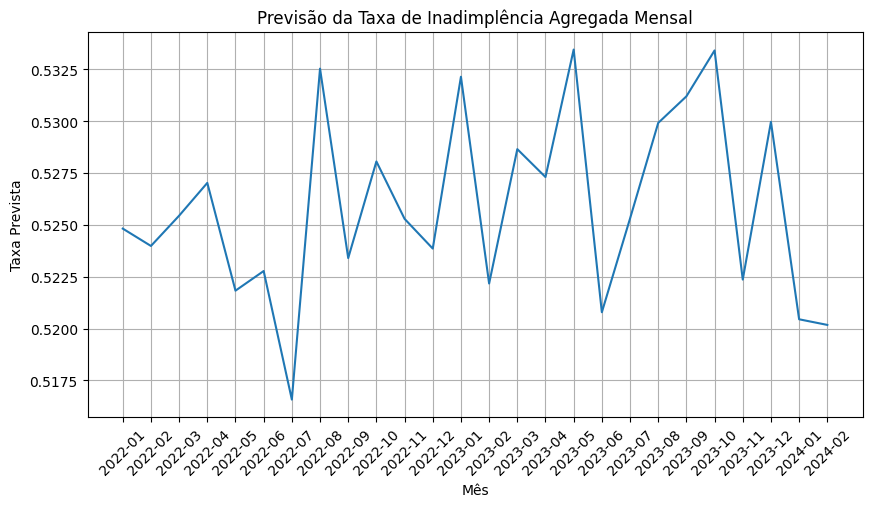

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(previsao_mensal["mes_referencia"], previsao_mensal["taxa_inadimplencia_prevista"])
plt.xticks(rotation=45)
plt.title("Previsão da Taxa de Inadimplência Agregada Mensal")
plt.ylabel("Taxa Prevista")
plt.xlabel("Mês")
plt.grid(True)
plt.show()